# DS539 Season Watch

### Precipitation


This file is created for analyzing how does precipitation correlates with tree phenology, specifically across the nation of India.



Sources: 

Precipitation dataset: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-monthly-means?tab=overview

Tree Phenology dataset: https://github.com/BU-Spark/ds-seasonwatch-trees

For accessing datasets used in this notebook:\
Original precipitation dataset in GRIB: https://drive.google.com/file/d/12wkM-U_kzmDMb-vLNCzGHYYVT6ZggKrE/view?usp=drive_link \
Cleaned weekly phenology dataset in csv: https://drive.google.com/file/d/1BYfni7iyLVUWyZRxTYu-9Rj1kpADjUnF/view?usp=drive_link \
Cleaned weekly precipitation dataset in csv: https://drive.google.com/file/d/1U2um_bkmchlq-bw6q9D4xO0uHGCxsd7s/view?usp=drive_link


### Part 1: Initial Setup for Precipitation Dataset

Load precipitation dataset in GRIB format into VScode

In [5]:
import xarray as xr
import pandas as pd
import numpy as np
ds_p = xr.open_dataset('../../data/spring_2025_data/precip_data/data.grib', engine='cfgrib')

# preview the dataset
print(ds_p)

Ignoring index file '../../data/spring_2025_data/precip_data/data.grib.5b7b6.idx' incompatible with GRIB file


<xarray.Dataset> Size: 6GB
Dimensions:     (time: 72, latitude: 1801, longitude: 3600)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 576B 2018-01-01 2018-02-01 ... 2023-12-01
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude   (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
    valid_time  (time) datetime64[ns] 576B ...
Data variables:
    tp          (time, latitude, longitude) float32 2GB ...
    lai_hv      (time, latitude, longitude) float32 2GB ...
    lai_lv      (time, latitude, longitude) float32 2GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:      

/Users/gzs/anaconda3/envs/grib_env/lib/python3.10/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [3]:
# Preview the headers of precipitation dataset
subset = ds_p.sel(
    time=slice(ds_p.time.min().values, ds_p.time.max().values),
    latitude=slice(ds_p.latitude.max().values, ds_p.latitude.min().values),  # descending
    longitude=slice(ds_p.longitude.min().values, ds_p.longitude.max().values)
)

df_p = subset.to_dataframe().reset_index()
df_p.head(10)

,time,latitude,longitude,number,step,surface,valid_time,tp,lai_hv,lai_lv
0,2018-01-01,90.0,0.0,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
1,2018-01-01,90.0,0.1,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
2,2018-01-01,90.0,0.2,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
3,2018-01-01,90.0,0.3,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
4,2018-01-01,90.0,0.4,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
5,2018-01-01,90.0,0.5,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
6,2018-01-01,90.0,0.6,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
7,2018-01-01,90.0,0.7,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
8,2018-01-01,90.0,0.8,0,1 days,0.0,2018-01-02,NaN,NaN,NaN
9,2018-01-01,90.0,0.9,0,1 days,0.0,2018-01-02,NaN,NaN,NaN


Data Cleaning

In [4]:
# Drop non-informative columns
df_p_clean = df_p.drop(columns=['number','step','valid_time'])

# Drop rows with nulls
df_p_clean = df_p_clean.dropna()

# Final Preview
df_p_clean.head(10)

,time,latitude,longitude,surface,tp,lai_hv,lai_lv
237234,2018-01-01,83.5,323.4,0.0,0.000484,0.0,0.0
237235,2018-01-01,83.5,323.5,0.0,0.000484,0.0,0.0
237236,2018-01-01,83.5,323.6,0.0,0.000484,0.0,0.0
237237,2018-01-01,83.5,323.7,0.0,0.000484,0.0,0.0
237238,2018-01-01,83.5,323.8,0.0,0.000484,0.0,0.0
237239,2018-01-01,83.5,323.9,0.0,0.000484,0.0,0.0
237240,2018-01-01,83.5,324.0,0.0,0.000485,0.0,0.0
237241,2018-01-01,83.5,324.1,0.0,0.000488,0.0,0.0
237242,2018-01-01,83.5,324.2,0.0,0.000491,0.0,0.0
237243,2018-01-01,83.5,324.3,0.0,0.000494,0.0,0.0


In [5]:
# Getting the attributes of the variables
print(ds_p['tp'].attrs)

{'GRIB_paramId': 228, 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': 6483600, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'avgad', 'GRIB_gridType': 'regular_ll', 'GRIB_uvRelativeToGrid': 0, 'GRIB_NV': 0, 'GRIB_Nx': 3600, 'GRIB_Ny': 1801, 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'tp', 'GRIB_gridDefinitionDescription': 'Latitude/Longitude Grid', 'GRIB_iDirectionIncrementInDegrees': 0.1, 'GRIB_iScansNegatively': 0, 'GRIB_jDirectionIncrementInDegrees': 0.1, 'GRIB_jPointsAreConsecutive': 0, 'GRIB_jScansPositively': 0, 'GRIB_latitudeOfFirstGridPointInDegrees': 90.0, 'GRIB_latitudeOfLastGridPointInDegrees': -90.0, 'GRIB_longitudeOfFirstGridPointInDegrees': 0.0, 'GRIB_longitudeOfLastGridPointInDegrees': 359.9, 'GRIB_missingValue': 3.4028234663852886e+38, 'GRIB_name': 'Total precipitation', 'GRIB_shortName': 'tp', 'GRIB_totalNumber': 0, 'GRIB_units': 'm', 'long_name': 'Total precipitation', 'units': 'm', 'standard_name': 'unknown'}


In [6]:
# Convert unit of 'total precipitation' from meters to millimeters
df_p_clean['tp'] = df_p_clean['tp'] * 1000
df_p_clean = df_p_clean.rename(columns={'tp': 'total precipitation(in mm)'})

# Reset index after cleaning
df_p_clean.reset_index(drop=True, inplace=True)
df_p_clean.head(5)

,time,latitude,longitude,surface,total precipitation(in mm),lai_hv,lai_lv
0,2018-01-01,83.5,323.4,0.0,0.484233,0.0,0.0
1,2018-01-01,83.5,323.5,0.0,0.484233,0.0,0.0
2,2018-01-01,83.5,323.6,0.0,0.484233,0.0,0.0
3,2018-01-01,83.5,323.7,0.0,0.484233,0.0,0.0
4,2018-01-01,83.5,323.8,0.0,0.484233,0.0,0.0


### Part 2: Initial Setup for Tree Phenology Dataset

Load the tree phenology downloaded from Github in CSV format into VSCode

In [7]:
df_tree = pd.read_csv("../../data/Fall 2024 data/cleaned_alldata_version2.csv")

# Preview the structure
print(df_tree.shape)
print(df_tree.columns)
df_tree.head(3)

(571834, 19)
Index(['Unnamed: 0', 'Date_of_observation', 'Species_name', 'Lat', 'Long',
       'State_name', 'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
       'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
       'Fruits_unripe', 'Fruits_ripe', 'Fruits_open', 'Year', 'Week',
       'Species_id'],
      dtype='object')


,Unnamed: 0,Date_of_observation,Species_name,Lat,Long,State_name,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open,Year,Week,Species_id
0,1,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
1,2,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
2,3,2020-01-01,Fish-tail Palm-Caryota urens,12.14060,75.22145,Kerala,0.0,2.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1019.0


Data Cleaning

In [8]:
# Drop 'Unnamed:0' column
df_tree_clean = df_tree.drop(columns=['Unnamed: 0'])

# Dropping rows that contain null
df_tree_clean = df_tree_clean.dropna()

# Show updated version
df_tree_clean.info()
df_tree_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 136258 entries, 0 to 571830
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date_of_observation  136258 non-null  object 
 1   Species_name         136258 non-null  object 
 2   Lat                  136258 non-null  float64
 3   Long                 136258 non-null  float64
 4   State_name           136258 non-null  object 
 5   Leaves_fresh         136258 non-null  float64
 6   Leaves_mature        136258 non-null  float64
 7   Leaves_old           136258 non-null  float64
 8   Flowers_bud          136258 non-null  float64
 9   Flowers_open         136258 non-null  float64
 10  Flowers_male         136258 non-null  float64
 11  Flowers_Female       136258 non-null  float64
 12  Fruits_unripe        136258 non-null  float64
 13  Fruits_ripe          136258 non-null  float64
 14  Fruits_open          136258 non-null  float64
 15  Year                 1

,Date_of_observation,Species_name,Lat,Long,State_name,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,Flowers_male,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open,Year,Week,Species_id
0,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
1,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0
2,2020-01-01,Fish-tail Palm-Caryota urens,12.14060,75.22145,Kerala,0.0,2.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1019.0
3,2020-01-01,Mast Tree-Monoon longifolium,12.14060,75.22145,Kerala,1.0,2.0,0.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1065.0
4,2020-01-01,Indian Almond-Terminalia catappa,12.14060,75.22145,Kerala,0.0,1.0,2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,2020.0,0,1085.0


In [9]:
# Save these 2 files 
df_tree_clean.to_csv("df_tree_clean.csv", index=False)
df_p_clean.to_csv("df_p_clean.csv", index=False)

In [1]:
import pandas as pd

df_tree_clean = pd.read_csv("/Users/gzs/Desktop/Hi/BU/DS539/ds-seasonwatch-trees/code/spring_2025_code/df_tree_clean.csv")

df_p_clean = pd.read_csv("/Users/gzs/Desktop/Hi/BU/DS539/ds-seasonwatch-trees/code/spring_2025_code/df_p_clean.csv")


Horizontal Pie Chart: Tree Phenology Observations by State

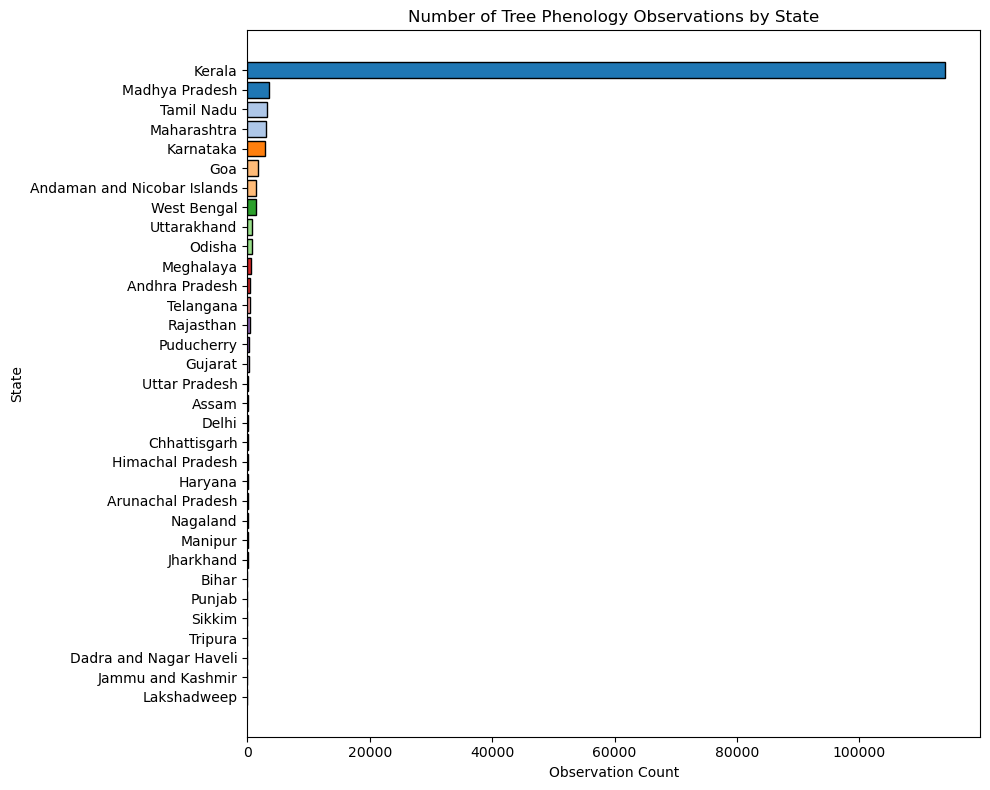

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Count observations per state
state_counts = df_tree_clean['State_name'].value_counts()

# Set up a colormap
colors = plt.cm.tab20(np.linspace(0, 1, len(state_counts)))

# Plot
plt.figure(figsize=(10, 8))
plt.barh(state_counts.index, state_counts.values, color=colors, edgecolor='black')

# Styling
plt.title("Number of Tree Phenology Observations by State")
plt.xlabel("Observation Count")
plt.ylabel("State")
plt.gca().invert_yaxis()  # Highest at the top
plt.tight_layout()

plt.show()


 Phenology Observation Frequency Over Time

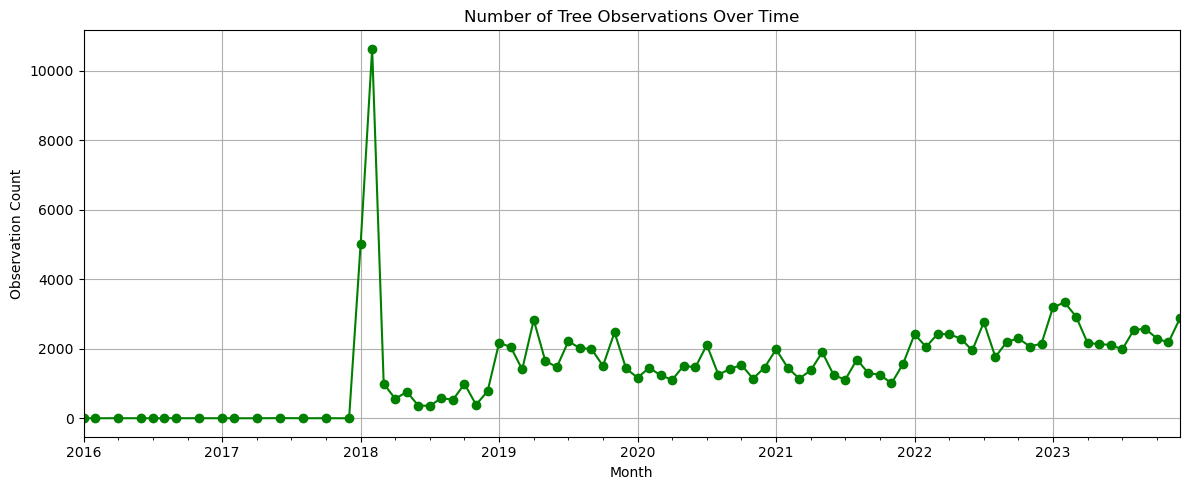

In [2]:
import matplotlib.pyplot as plt

# Convert date column 
df_tree_clean['Date_of_observation'] = pd.to_datetime(df_tree_clean['Date_of_observation'])

# Count number of phenology observations per month
obs_per_month = df_tree_clean.groupby(df_tree_clean['Date_of_observation'].dt.to_period('M')).size()

# Plot
obs_per_month.plot(kind='line', figsize=(12, 5), color='green', marker='o')
plt.title("Number of Tree Observations Over Time")
plt.xlabel("Month")
plt.ylabel("Observation Count")
plt.grid(True)
plt.tight_layout()
plt.show()


Histogram of Phenophase Scores

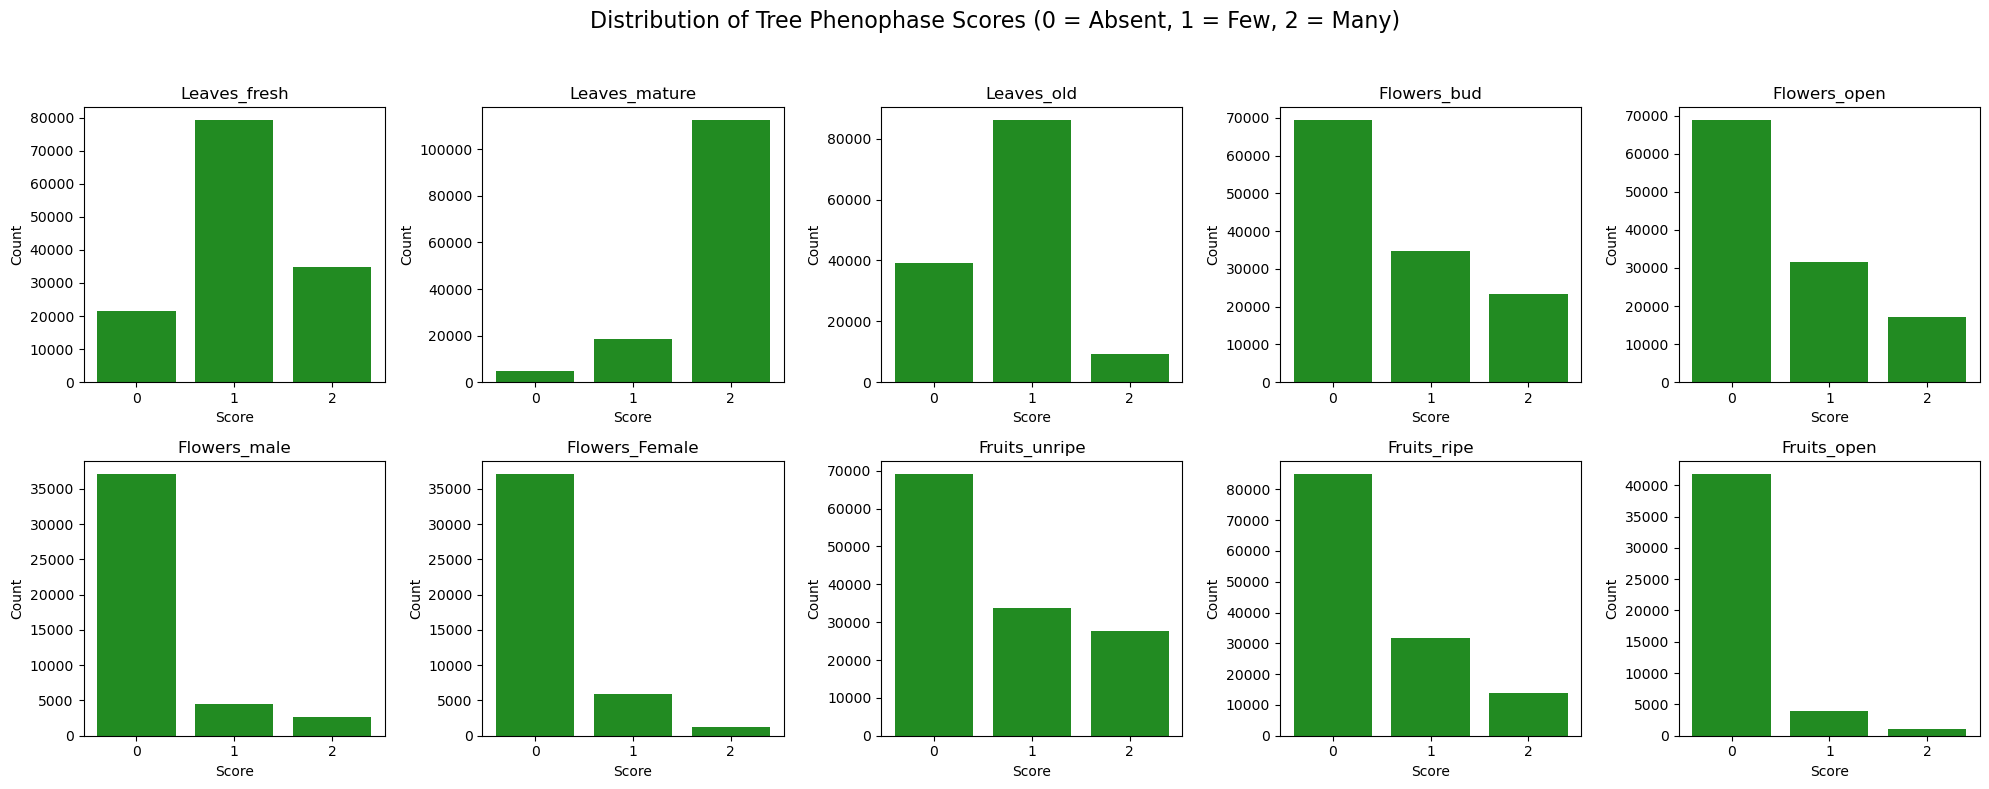

In [8]:
phenophase_cols = [
    'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
    'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
    'Fruits_unripe', 'Fruits_ripe', 'Fruits_open'
]

# Set up the plot grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(phenophase_cols):
    # Replace -2 with NaN to ignore 'no observation'
    clean_data = df_tree_clean[col].replace(-2, np.nan).dropna()
    
    axes[i].hist(clean_data, bins=[-0.5, 0.5, 1.5, 2.5], rwidth=0.8, color='forestgreen')
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of Tree Phenophase Scores (0 = Absent, 1 = Few, 2 = Many)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Precipitation Over Time

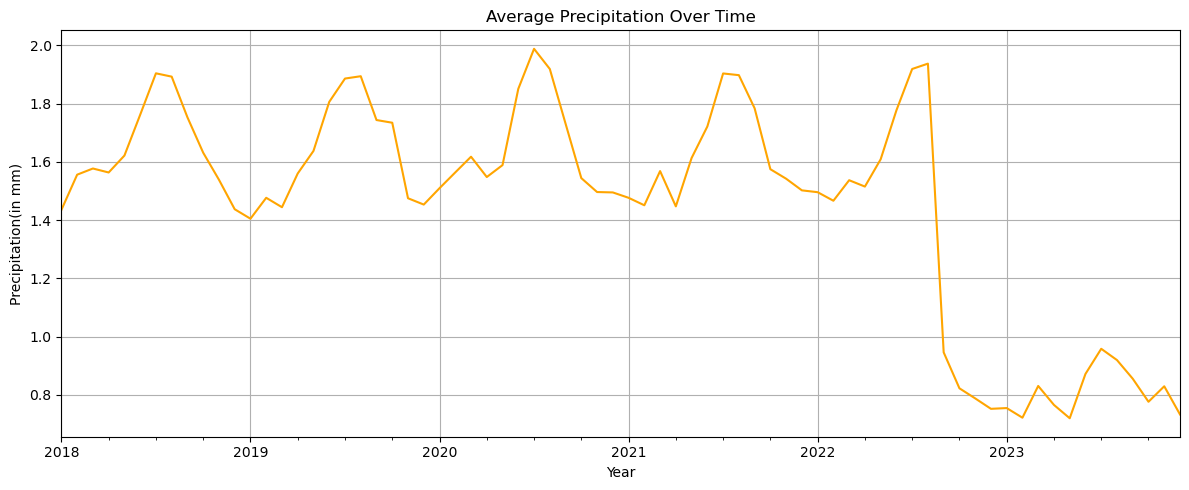

In [9]:
df_p_clean['time'] = pd.to_datetime(df_p_clean['time'])

precip_time_series = df_p_clean.groupby('time')['total precipitation(in mm)'].mean()

precip_time_series.plot(figsize=(12, 5), color='orange')
plt.title("Average Precipitation Over Time")
plt.xlabel("Year")
plt.ylabel("Precipitation(in mm)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Part 3: Merge Datasets

Merge the precipitation dataset with the tree phenology dataset together for further analysis

In [21]:
# Ensure Date_of_observation is datetime
df_tree_clean['Date_of_observation'] = pd.to_datetime(df_tree_clean['Date_of_observation'], errors='coerce')

# Extract Year and ISO Week number
df_tree_clean['Year'] = df_tree_clean['Date_of_observation'].dt.year
df_tree_clean['Week'] = df_tree_clean['Date_of_observation'].dt.isocalendar().week

# Ensure 'time' column is datetime
df_p_clean['time'] = pd.to_datetime(df_p_clean['time'], errors='coerce')

# Extract Year and ISO Week
df_p_clean['Year'] = df_p_clean['time'].dt.year
df_p_clean['Week'] = df_p_clean['time'].dt.isocalendar().week


In [22]:
# Ensure Year and Week are integers
df_tree_clean['Year'] = df_tree_clean['Year'].astype(int)
df_tree_clean['Week'] = df_tree_clean['Week'].astype(int)

df_p_clean['Year'] = df_p_clean['Year'].astype(int)
df_p_clean['Week'] = df_p_clean['Week'].astype(int)

In [23]:
# Round coordinates to 1 decimal place
df_tree_clean['Lat_round'] = df_tree_clean['Lat'].round(1)
df_tree_clean['Long_round'] = df_tree_clean['Long'].round(1) 

df_p_clean['Lat_round'] = df_p_clean['latitude'].round(1)
df_p_clean['Long_round'] = df_p_clean['longitude'].round(1)

In [24]:
# Define the phenophase columns
phenophase_cols = [
    'Leaves_fresh', 'Leaves_mature', 'Leaves_old',
    'Flowers_bud', 'Flowers_open', 'Flowers_male', 'Flowers_Female',
    'Fruits_unripe', 'Fruits_ripe', 'Fruits_open'
]

# Replace -2 (no observation) with 0 (so it doesn't count as activity)
df_tree_clean[phenophase_cols] = df_tree_clean[phenophase_cols].replace(-2, 0)

In [25]:
# Sum across all phenophase columns
df_tree_clean['phenophase_score'] = df_tree_clean[phenophase_cols].sum(axis=1)

# Preview result
df_tree_clean.head(2)

,Date_of_observation,Species_name,Lat,Long,State_name,Leaves_fresh,Leaves_mature,Leaves_old,Flowers_bud,Flowers_open,...,Flowers_Female,Fruits_unripe,Fruits_ripe,Fruits_open,Year,Week,Species_id,Lat_round,Long_round,phenophase_score
0,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2020,1,1085.0,12.2,75.2,2.0
1,2020-01-01,Indian Almond-Terminalia catappa,12.15386,75.22397,Kerala,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2020,1,1085.0,12.2,75.2,2.0


In [26]:
# Group by Year, Week, and Location
df_weekly_pheno = df_tree_clean.groupby(
    ['Year', 'Week', 'Lat_round', 'Long_round']
)['phenophase_score'].mean().reset_index()

# Preview result
df_weekly_pheno.head(100000)

,Year,Week,Lat_round,Long_round,phenophase_score
0,2016,1,8.6,76.8,8.000000
1,2016,5,8.6,76.8,8.000000
2,2016,13,8.6,76.8,8.000000
3,2016,14,8.6,76.8,8.000000
4,2016,23,8.6,76.8,8.000000
...,...,...,...,...,...
14444,2023,50,27.6,80.1,4.000000
14445,2023,50,28.5,77.2,5.000000
14446,2023,50,28.6,77.2,0.000000
14447,2023,50,31.0,76.5,5.333333


In [27]:
# Check all years in precipitation dataset
years = sorted(df_p_clean['Year'].dropna().unique())
print('Years in precipitation dataset:', years)

Years in precipitation dataset: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [30]:
# Container for storing results
df_weekly_precip_list = []

for year in years:
    print(f"Processing year: {year}")

    # Filter data for this year
    df_year = df_p_clean[df_p_clean['Year'] == year].copy()

    # Rename column
    df_year = df_year.rename(columns={'total precipitation(in mm)': 'precip_mm'})

    # Group by week and location
    grouped = df_year.groupby(
        ['Year', 'Week', 'Lat_round', 'Long_round']
    )['precip_mm'].mean().reset_index()
    
    df_weekly_precip_list.append(grouped)

# Combine all years together
df_weekly_precip = pd.concat(df_weekly_precip_list, ignore_index=True)

# Preview
df_weekly_precip.head()

Processing year: 2018
Processing year: 2019
Processing year: 2020
Processing year: 2021
Processing year: 2022
Processing year: 2023


,Year,Week,Lat_round,Long_round,precip_mm
0,2018,1,-90.0,0.0,0.132678
1,2018,1,-90.0,0.1,0.132678
2,2018,1,-90.0,0.2,0.132678
3,2018,1,-90.0,0.3,0.132678
4,2018,1,-90.0,0.4,0.132678


In [ ]:
df_weekly_precip = pd.read_csv('../../data/spring_2025_data/precip_data/weekly_precip_cleaned.csv')
df_weekly_pheno = pd.read_csv('../../data/spring_2025_data/precip_data/weekly_pheno_cleaned.csv')

In [31]:
df_weekly_precip = df_weekly_precip[
        (df_weekly_precip['Lat_round'].between(6.5,37.5)) &
        (df_weekly_precip['Long_round'].between(68.0,97.5))
].copy()
df_weekly_precip = df_weekly_precip.reset_index(drop=True)
df_weekly_precip = df_weekly_precip.drop(columns=['Unnamed: 0'], errors='ignore')
df_weekly_pheno = df_weekly_pheno.drop(columns=['Unnamed: 0'], errors='ignore')


In [ ]:
df_weekly_precip.head(5)

,Unnamed: 0.1,Year,Week,Lat_round,Long_round,precip_mm
0,1021031,2018,1,6.5,80.0,1.067413
1,1021032,2018,1,6.5,80.1,1.200450
2,1021033,2018,1,6.5,80.2,1.572532
3,1021034,2018,1,6.5,80.3,2.161739
4,1021035,2018,1,6.5,80.4,2.751035


In [ ]:
df_weekly_pheno.head(5)

,Year,Week,Lat_round,Long_round,phenophase_score
0,2016,1,8.6,76.8,8.0
1,2016,5,8.6,76.8,8.0
2,2016,13,8.6,76.8,8.0
3,2016,14,8.6,76.8,8.0
4,2016,23,8.6,76.8,8.0


Average Precipitation Over Time (Weekly)

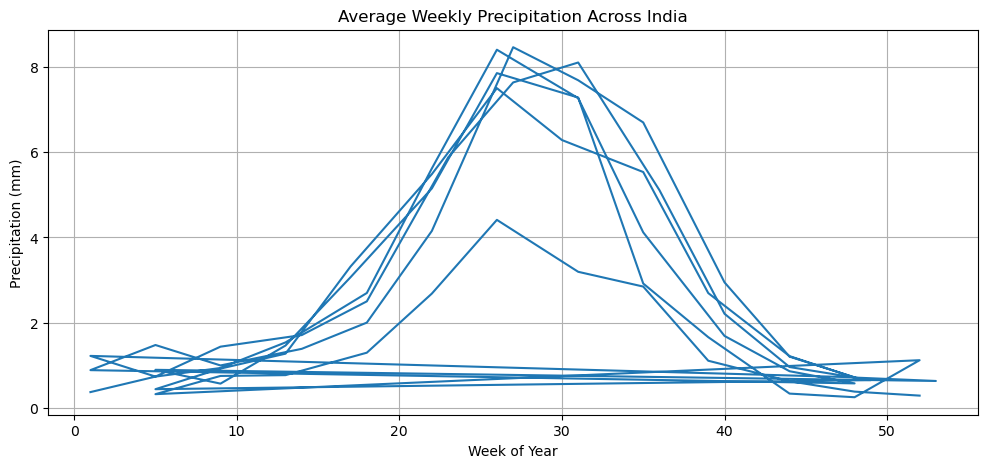

In [32]:
import matplotlib.pyplot as plt

# Aggregate national average weekly precipitation
precip_trend = df_weekly_precip.groupby(['Year', 'Week'])['precip_mm'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(precip_trend['Week'], precip_trend['precip_mm'])
plt.title("Average Weekly Precipitation Across India")
plt.xlabel("Week of Year")
plt.ylabel("Precipitation (mm)")
plt.grid(True)
plt.show()

Average Phenophase Score Over Time (Weekly)

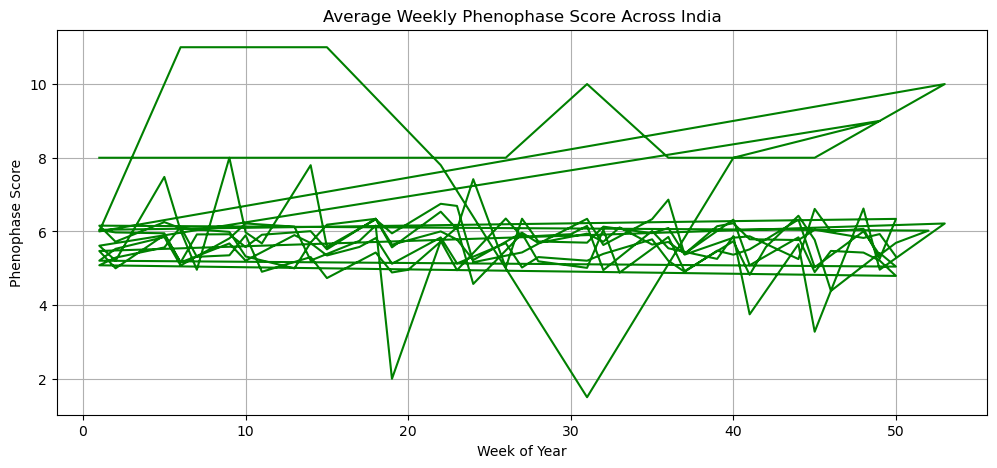

In [33]:
pheno_trend = df_weekly_pheno.groupby(['Year', 'Week'])['phenophase_score'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(pheno_trend['Week'], pheno_trend['phenophase_score'], color='green')
plt.title("Average Weekly Phenophase Score Across India")
plt.xlabel("Week of Year")
plt.ylabel("Phenophase Score")
plt.grid(True)
plt.show()

Precipitation Grid Coverage Spatial Map

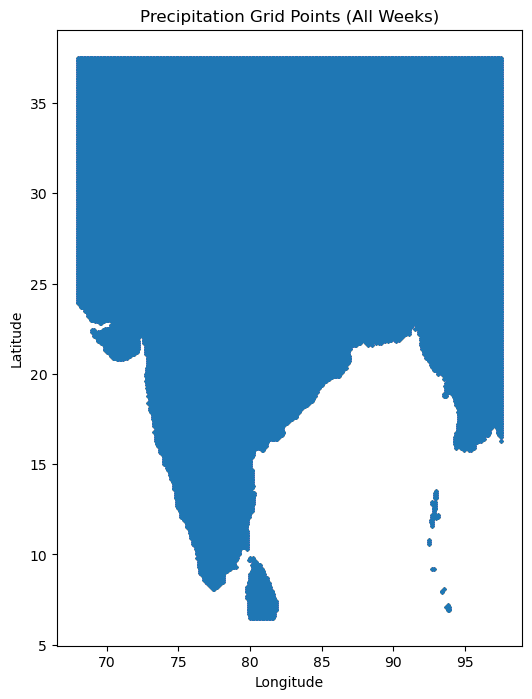

In [34]:
plt.figure(figsize=(6, 8))
plt.scatter(df_weekly_precip['Long_round'], df_weekly_precip['Lat_round'], alpha=0.3, s=2)
plt.title("Precipitation Grid Points (All Weeks)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Tree Observation Density Spatial Map

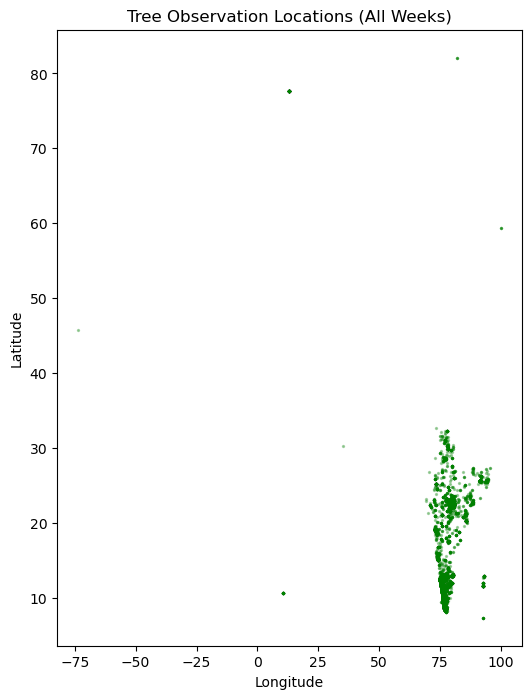

In [35]:
plt.figure(figsize=(6, 8))
plt.scatter(df_weekly_pheno['Long_round'], df_weekly_pheno['Lat_round'], alpha=0.3, s=2, color='green')
plt.title("Tree Observation Locations (All Weeks)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Implement KDTree for fast nearest neighbor lookup so we are not merging strictly on identical latitudes and longitudes. 


In [36]:

from scipy.spatial import cKDTree
import numpy as np

# Build KDTree using precip grid coordinates
precip_coords = df_weekly_precip[['Lat_round', 'Long_round']].drop_duplicates().values
tree = cKDTree(precip_coords)

# Query for nearest grid cell for each pheno row
pheno_coords = df_weekly_pheno[['Lat_round', 'Long_round']].values
distances, indices = tree.query(pheno_coords, distance_upper_bound=0.8)  

# Filter out unmatched rows 
valid_mask = np.isfinite(distances)
df_weekly_pheno_valid = df_weekly_pheno[valid_mask].copy()

# Map to nearest precip grid coords
nearest_coords = precip_coords[indices[valid_mask]]
df_weekly_pheno_valid['Lat_round'] = nearest_coords[:, 0]
df_weekly_pheno_valid['Long_round'] = nearest_coords[:, 1]

# Merge using matched grid + week
df_merged = pd.merge(
    df_weekly_pheno_valid,
    df_weekly_precip,
    on=['Year', 'Week', 'Lat_round', 'Long_round'],
    how='inner',
    indicator=True
)

# Preview
df_merged.head()


,Year,Week,Lat_round,Long_round,phenophase_score,precip_mm,_merge
0,2018,1,8.3,77.1,7.272727,0.390378,both
1,2018,1,8.3,77.1,6.676190,0.390378,both
2,2018,1,8.4,77.1,6.000000,0.557152,both
3,2018,1,8.6,76.8,11.000000,0.542668,both
4,2018,1,9.2,76.5,4.000000,0.588251,both


In [37]:
df_merged.shape

(4561, 7)

In [38]:
df_merged.to_csv("/Users/gzs/Desktop/Hi/BU/DS539/ds-seasonwatch-trees/data/spring_2025_data/precip_data/df_merged.csv", index=False)


### Part 4: Analysis 

Check how strongly phenophase activity correlates with precipitation

In [39]:
correlation = df_merged[['phenophase_score', 'precip_mm']].corr()
print(correlation)


                  phenophase_score  precip_mm
phenophase_score          1.000000  -0.005678
precip_mm                -0.005678   1.000000


Conclusion: By looking at the precipitation along, we will not see a clear linear relationship between tree phenology and precipitation, with following possible reasons:
1. Trees have lagged response to precipitation
2. Non-linear relationship overall, but may exist in certain states, times, or species
3. Other compounding factors: light, temerature, soil... 

Scatter plot: Visualize the relationship between phenophase activity and precipitation

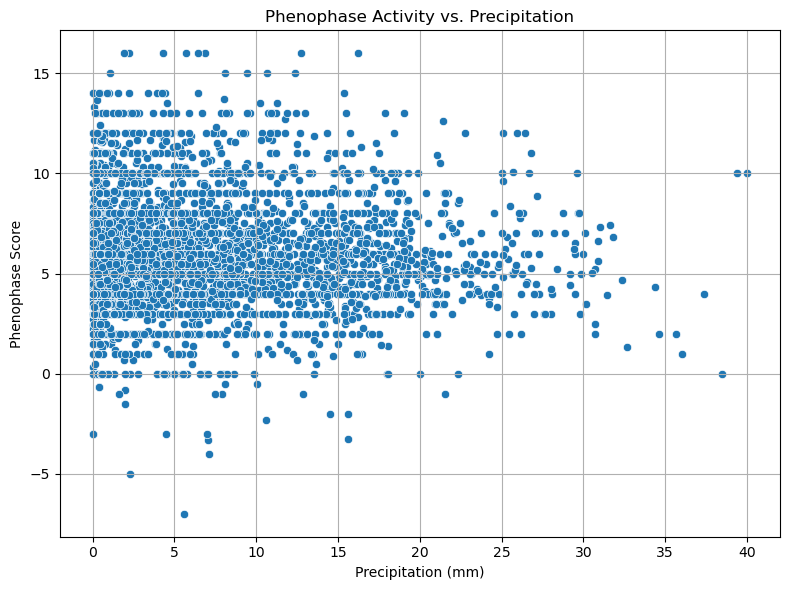

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_merged, x='precip_mm', y='phenophase_score')
plt.title("Phenophase Activity vs. Precipitation")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Phenophase Score")
plt.grid(True)
plt.tight_layout()
plt.show()


Trend Over Time: How phenophase activity and precipitation vary across weeks

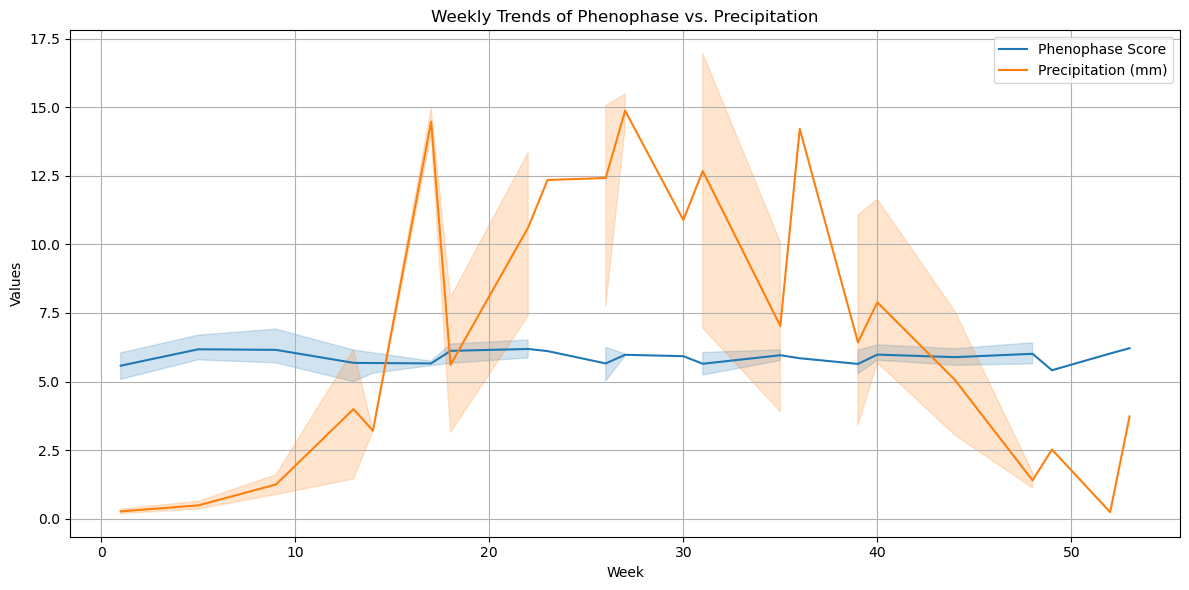

In [41]:
df_grouped = df_merged.groupby(['Year', 'Week'])[['phenophase_score', 'precip_mm']].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='Week', y='phenophase_score', label='Phenophase Score')
sns.lineplot(data=df_grouped, x='Week', y='precip_mm', label='Precipitation (mm)')
plt.title("Weekly Trends of Phenophase vs. Precipitation")
plt.xlabel("Week")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


HeatMap: How average values vary acorss locations

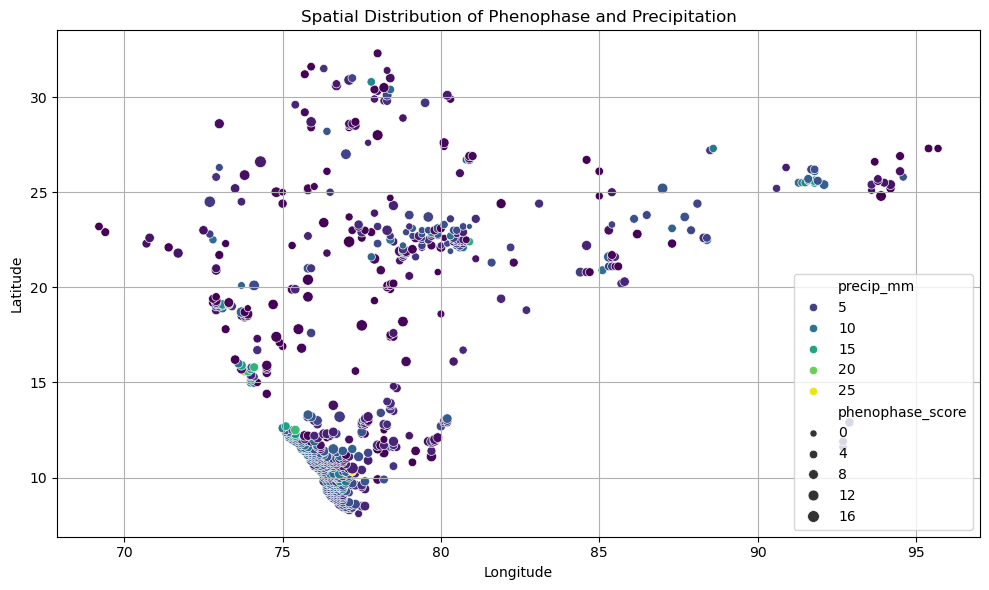

In [42]:
location_avg = df_merged.groupby(['Lat_round', 'Long_round'])[['phenophase_score', 'precip_mm']].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=location_avg, x='Long_round', y='Lat_round', size='phenophase_score', hue='precip_mm', palette='viridis')
plt.title("Spatial Distribution of Phenophase and Precipitation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()
